# Baseline 1: ResNet18 + Prototypical Network (Few-Shot Learning)

This notebook runs **1-shot, 5-shot, and 10-shot** experiments.

## Imports

In [9]:
import os, random
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Performance Optimization: Enable Apple Silicon GPU and Multi-Core CPU
import torch

# Enable all CPU cores
torch.set_num_threads(torch.get_num_threads())

# Check available accelerators
if torch.backends.mps.is_available():
    print(f"✓ Apple Silicon GPU (MPS) is available - Training will be accelerated!")
    print(f"  Device: {torch.backends.mps.is_built()}")
elif torch.cuda.is_available():
    print(f"✓ NVIDIA GPU (CUDA) is available")
    print(f"  Device: {torch.cuda.get_device_name(0)}")
else:
    print(f"✓ Using CPU with {torch.get_num_threads()} threads")

print(f"\nPyTorch version: {torch.__version__}")

✓ Apple Silicon GPU (MPS) is available - Training will be accelerated!
  Device: True

PyTorch version: 2.8.0


## Image Transform

In [11]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Few-Shot Dataset (Episodic Sampling)

In [12]:
class FewShotDataset:
    def __init__(self, root_dir, transform):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_images = {
            cls: os.listdir(os.path.join(root_dir, cls))
            for cls in self.classes
        }

    def sample_episode(self, n_way, k_shot, q_query):
        support_images, support_labels = [], []
        query_images, query_labels = [], []

        selected_classes = random.sample(self.classes, n_way)

        for label, cls in enumerate(selected_classes):
            # Handle insufficient images by reusing available ones
            images = self.class_to_images[cls]
            if len(images) < k_shot + q_query:
                # print(f"⚠️ Not enough images in class '{cls}'. Reusing available images.")
                images = (images * ((k_shot + q_query) // len(images) + 1))[:k_shot + q_query]

            sampled_images = random.sample(images, k_shot + q_query)
            cls_path = os.path.join(self.root_dir, cls)

            for img_name in sampled_images[:k_shot]:
                img = Image.open(os.path.join(cls_path, img_name)).convert("RGB")
                support_images.append(self.transform(img))
                support_labels.append(label)

            for img_name in sampled_images[k_shot:]:
                img = Image.open(os.path.join(cls_path, img_name)).convert("RGB")
                query_images.append(self.transform(img))
                query_labels.append(label)

        return (
            torch.stack(support_images),
            torch.tensor(support_labels),
            torch.stack(query_images),
            torch.tensor(query_labels)
        )

## ResNet18 Encoder

In [13]:
class ResNet18Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder = nn.Sequential(*list(resnet.children())[:-1])

    def forward(self, x):
        x = self.encoder(x)
        return x.view(x.size(0), -1)

## Prototypical Network

In [14]:
class ProtoNet(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

    def forward(self, support_x, support_y, query_x):
        support_emb = self.encoder(support_x)
        query_emb = self.encoder(query_x)

        prototypes = []
        for c in torch.unique(support_y):
            prototypes.append(support_emb[support_y == c].mean(0))
        prototypes = torch.stack(prototypes)

        distances = torch.cdist(query_emb, prototypes)
        return -distances

## Training & Evaluation

In [15]:
def train_and_evaluate(k_shot):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_data = FewShotDataset("clean_dataset/train", transform)
    val_data = FewShotDataset("clean_dataset/val", transform)

    model = ProtoNet(ResNet18Encoder()).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Train
    model.train()
    for episode in range(100):
        print(f"Training episode {episode + 1}/100...")
        sx, sy, qx, qy = train_data.sample_episode(4, k_shot, 10)
        sx, sy, qx, qy = sx.to(device), sy.to(device), qx.to(device), qy.to(device)

        scores = model(sx, sy, qx)
        loss = F.cross_entropy(scores, qy)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for eval_episode in range(50):
            print(f"Evaluating episode {eval_episode + 1}/50...")
            sx, sy, qx, qy = val_data.sample_episode(4, k_shot, 10)
            sx, sy, qx, qy = sx.to(device), sy.to(device), qx.to(device), qy.to(device)
            preds = model(sx, sy, qx).argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(qy.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    return acc, cm

## 📊 Enhanced Evaluation with Comprehensive Metrics

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import seaborn as sns

def train_and_evaluate_with_metrics(n_support_list=[1, 5, 10], n_way=4, n_query=15,
                                     n_train_episodes=100, n_eval_episodes=100,
                                     learning_rate=0.001):
    """Train + evaluate for each shot count. No external variables needed."""

    # Device selection: MPS (Apple Silicon) > CUDA > CPU
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using device: MPS (Apple Silicon GPU)")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using device: CUDA GPU")
    else:
        device = torch.device("cpu")
        print("Using device: CPU")

    train_data = FewShotDataset("clean_dataset/train", transform)
    test_data  = FewShotDataset("clean_dataset/test",  transform)

    results = {}

    for n_support in n_support_list:
        print(f"\n{'='*60}")
        print(f"  {n_support}-shot learning")
        print(f"{'='*60}")

        # Fresh encoder for each shot type
        encoder  = ResNet18Encoder().to(device)
        optimizer = torch.optim.Adam(encoder.parameters(), lr=learning_rate)

        # ---- Training ----
        encoder.train()
        for ep in range(n_train_episodes):
            sx, sy, qx, qy = train_data.sample_episode(n_way, n_support, n_query)
            sx, sy, qx, qy = sx.to(device), sy.to(device), qx.to(device), qy.to(device)

            support_emb = encoder(sx)
            query_emb   = encoder(qx)

            prototypes = torch.stack([support_emb[sy == c].mean(0) for c in range(n_way)])
            log_probs  = F.log_softmax(-torch.cdist(query_emb, prototypes), dim=1)
            loss       = F.nll_loss(log_probs, qy)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if (ep + 1) % 25 == 0:
                print(f"  Episode {ep+1}/{n_train_episodes}  loss={loss.item():.4f}")

        # ---- Evaluation ----
        encoder.eval()
        all_preds, all_labels, ep_accs = [], [], []

        with torch.no_grad():
            for _ in range(n_eval_episodes):
                sx, sy, qx, qy = test_data.sample_episode(n_way, n_support, n_query)
                sx, sy, qx, qy = sx.to(device), sy.to(device), qx.to(device), qy.to(device)

                support_emb = encoder(sx)
                query_emb   = encoder(qx)

                prototypes = torch.stack([support_emb[sy == c].mean(0) for c in range(n_way)])
                preds      = torch.argmin(torch.cdist(query_emb, prototypes), dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(qy.cpu().numpy())
                ep_accs.append((preds == qy).float().mean().item())

        all_preds  = np.array(all_preds)
        all_labels = np.array(all_labels)
        ep_accs    = np.array(ep_accs)

        acc       = accuracy_score(all_labels, all_preds)
        prec      = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        rec       = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        f1        = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        cm        = confusion_matrix(all_labels, all_preds)
        stab_mean = ep_accs.mean()
        stab_std  = ep_accs.std()
        stab_ci   = 1.96 * stab_std / np.sqrt(len(ep_accs))

        results[f'{n_support}-shot'] = {
            'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1,
            'confusion_matrix': cm,
            'stability_mean': stab_mean, 'stability_std': stab_std,
            'stability_ci': stab_ci, 'episode_accuracies': ep_accs
        }
        print(f"\n  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}")
        print(f"  Stability: {stab_mean:.4f} ± {stab_std:.4f}  (95% CI ±{stab_ci:.4f})")

    return results

### ▶️ Run Comprehensive Evaluation

In [17]:
# Runs training + evaluation for 1-shot, 5-shot, and 10-shot
results = train_and_evaluate_with_metrics(
    n_support_list=[1, 5, 10],
    n_way=4,
    n_query=15,
    n_train_episodes=2000,
    n_eval_episodes=1000,
    learning_rate=0.001
)

Using device: MPS (Apple Silicon GPU)

  1-shot learning
  Episode 25/2000  loss=0.0146
  Episode 50/2000  loss=0.2240
  Episode 75/2000  loss=0.0425
  Episode 100/2000  loss=0.0001
  Episode 125/2000  loss=0.0000
  Episode 150/2000  loss=0.0000
  Episode 175/2000  loss=0.0002
  Episode 200/2000  loss=0.0000
  Episode 225/2000  loss=0.0000
  Episode 250/2000  loss=0.0000
  Episode 275/2000  loss=0.0000
  Episode 300/2000  loss=0.0000
  Episode 325/2000  loss=0.0000
  Episode 350/2000  loss=0.0000
  Episode 375/2000  loss=0.0000
  Episode 400/2000  loss=0.0000
  Episode 425/2000  loss=0.0000
  Episode 450/2000  loss=0.0000
  Episode 475/2000  loss=0.0000
  Episode 500/2000  loss=0.0000
  Episode 525/2000  loss=0.0000
  Episode 550/2000  loss=0.0000
  Episode 575/2000  loss=0.0000
  Episode 600/2000  loss=0.0000
  Episode 625/2000  loss=0.0000
  Episode 650/2000  loss=0.0000
  Episode 675/2000  loss=0.0000
  Episode 700/2000  loss=0.0000
  Episode 725/2000  loss=0.0000
  Episode 750/2000

### 📈 Results Summary Table

In [18]:
metrics_data = []
for shot_type, m in results.items():
    metrics_data.append({
        'Shot Type':        shot_type,
        'Accuracy':         f"{m['accuracy']:.4f}",
        'Precision':        f"{m['precision']:.4f}",
        'Recall':           f"{m['recall']:.4f}",
        'F1-Score':         f"{m['f1_score']:.4f}",
        'Stability Mean':   f"{m['stability_mean']:.4f}",
        'Stability Std':    f"{m['stability_std']:.4f}",
        '95% CI':           f"±{m['stability_ci']:.4f}",
    })

df = pd.DataFrame(metrics_data)
print("=" * 95)
print("  BASELINE 1 — ResNet18 + Prototypical Networks")
print("=" * 95)
print(df.to_string(index=False))
print("=" * 95)

  BASELINE 1 — ResNet18 + Prototypical Networks
Shot Type Accuracy Precision Recall F1-Score Stability Mean Stability Std  95% CI
   1-shot   0.9091    0.9092 0.9091   0.9091         0.9091        0.0644 ±0.0040
   5-shot   0.9035    0.9035 0.9035   0.9035         0.9035        0.0405 ±0.0025
  10-shot   0.9214    0.9215 0.9214   0.9214         0.9214        0.0366 ±0.0023


### 🎯 Confusion Matrices (1-shot / 5-shot / 10-shot)

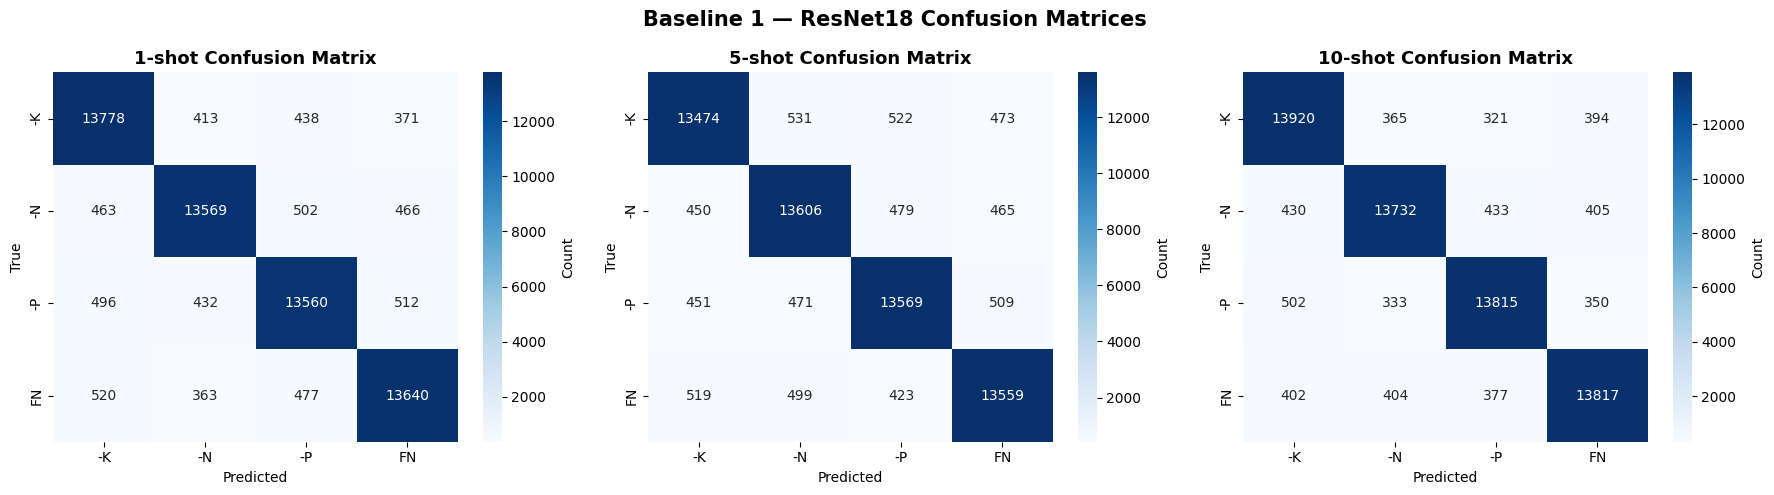

In [19]:
class_names = ['-K', '-N', '-P', 'FN']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (shot_type, m) in enumerate(results.items()):
    sns.heatmap(m['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx], cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{shot_type} Confusion Matrix', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.suptitle('Baseline 1 — ResNet18 Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 📉 Stability Analysis Across Episodes

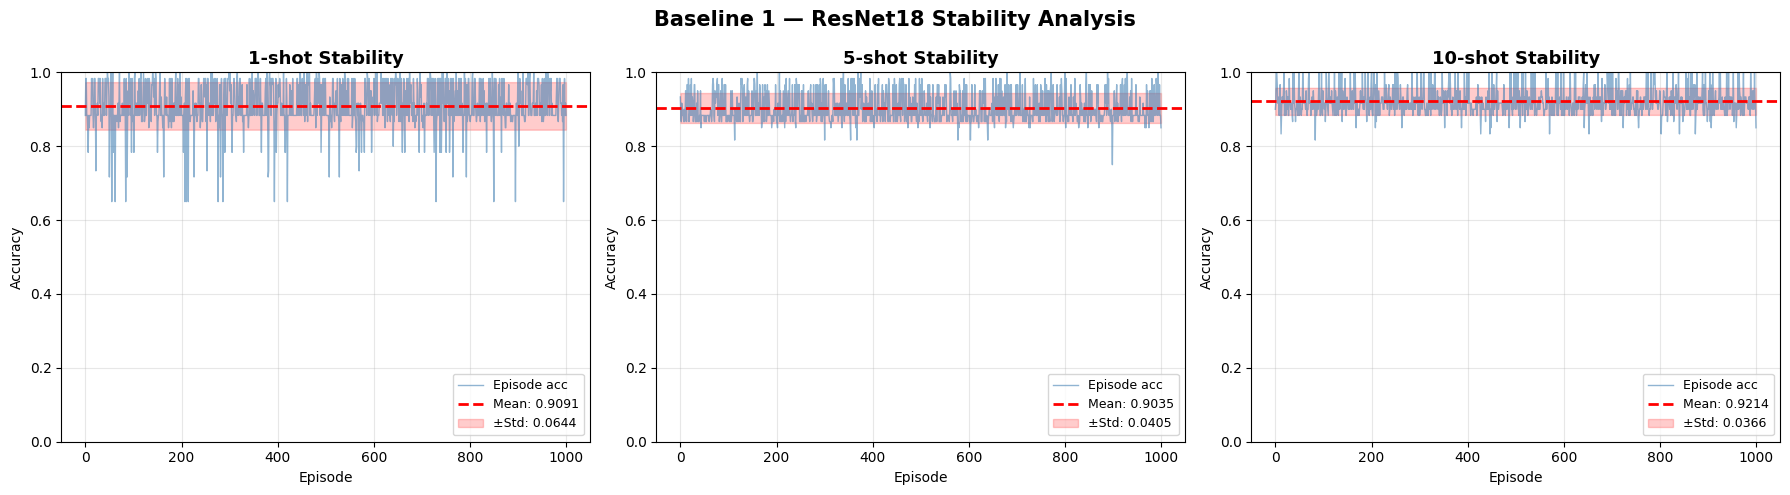

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (shot_type, m) in enumerate(results.items()):
    ep_accs = m['episode_accuracies']
    axes[idx].plot(ep_accs, alpha=0.6, linewidth=1, color='steelblue', label='Episode acc')
    axes[idx].axhline(m['stability_mean'], color='red', linestyle='--', linewidth=2,
                      label=f"Mean: {m['stability_mean']:.4f}")
    axes[idx].fill_between(range(len(ep_accs)),
                           m['stability_mean'] - m['stability_std'],
                           m['stability_mean'] + m['stability_std'],
                           alpha=0.2, color='red', label=f"±Std: {m['stability_std']:.4f}")
    axes[idx].set_title(f'{shot_type} Stability', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Episode')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].legend(loc='lower right', fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim([0, 1])

plt.suptitle('Baseline 1 — ResNet18 Stability Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()